In [1]:
import meep as mp
import meep.adjoint as mpa
from meep.materials import Au, Ag
import numpy as np
from autograd import numpy as npa
from autograd import tensor_jacobian_product, grad
import nlopt
from matplotlib import pyplot as plt
from matplotlib.patches import Circle
import os

In [2]:
dir_path = 'post-sim'
os.makedirs(dir_path, exist_ok=True)

setting is complete!


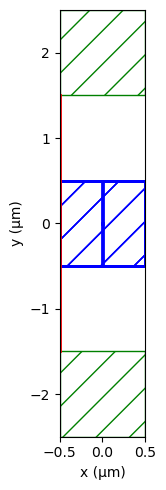

plot2D structure of Structure !


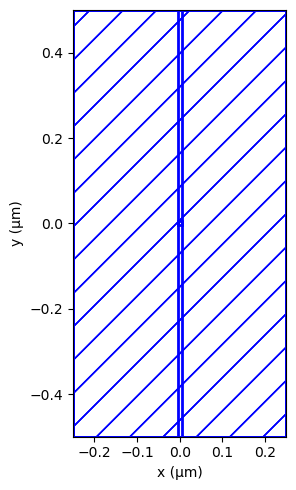

plot2D structure !


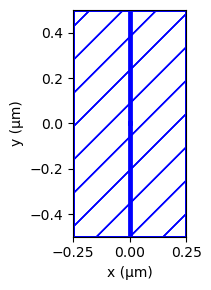

plot2D structure !


In [8]:
# Global parameters
mp.verbosity(0)
Air = mp.Medium(index=1)
Si = mp.Medium(index = 3.5)
resolution = 500 
dx = 1  #design_region_x_width = 1    
dy = 1  #design_region_y_width = 1   
pml_size = 1.0
air_size = 1.0
Sx = dx
Sy = dy + 2*pml_size + 2*air_size
cell_size = mp.Vector3(Sx, Sy)


# Mapping parameters
minimum_length = 0.02
eta_i = 0.5
eta_e = 0.55
eta_d = 1 - eta_e
filter_radius = mpa.get_conic_radius_from_eta_e(minimum_length, eta_e)
design_region_resolution = int(resolution)
pml_layers = [mp.PML(thickness=pml_size, direction=mp.Y)]

# Design frequency
wavelengths = np.array([1.55])
frequencies = np.array([1 / 1.55])
fcen = 1. / 1.55
width = 0.2
fwidth = width * fcen
source_center = mp.Vector3(-Sx/2,0) 
src_size = dy + 2* air_size
source_size = mp.Vector3(0,src_size) 
src = mp.GaussianSource(frequency=fcen, fwidth=fwidth,is_integrated=True)
source = [mp.Source(src, component=mp.Ey, size=source_size, center=source_center)]

# Design weight
Nx = int(design_region_resolution * dx) +1 
Ny = int(design_region_resolution * dy) +1
design_variables = mp.MaterialGrid(mp.Vector3(Nx, Ny), Air, Si, grid_type="U_MEAN")
design_region = mpa.DesignRegion(
    design_variables,
    volume=mp.Volume(
        center=mp.Vector3(0,0,0),
        size=mp.Vector3(dx, dy,0),
    ),
)

# binarize function 
def mapping(x, eta, beta):

    # filter
    filtered_field = mpa.conic_filter(
        x,
        filter_radius,
        dx,
        dy,
        design_region_resolution,
    )

    # projection
    projected_field = mpa.tanh_projection(filtered_field, beta, eta)

    # projected_field = (npa.fliplr(projected_field) + projected_field)/ 2  # up-down symmetry   
    
    projected_field = (npa.flipud(projected_field) + projected_field)/ 2  # left-right symmetry
    
    
    # interpolate to actual materials
    return projected_field.flatten()

# FOM 
def J(fields1,fields2):
    field1_integral = npa.sum(npa.abs(fields1) ** 2, axis=(1, 2))  # Shape: (n,)
    field2_integral = npa.sum(npa.abs(fields2) ** 2, axis=(1, 2))  # Shape: (n,)

    # Prevent division by zero
    # field2_integral = npa.where(field2_integral == 0, 1e-10, field2_integral)

   
    mean_field1 = npa.mean(field1_integral)  
    mean_field2 = npa.mean(field2_integral)  
    # Compute intensity ratio
    field_ratio = mean_field1 / mean_field2  
    return field_ratio
    
# Setting geometry
geometry = [      
    mp.Block(
        center=design_region.center, size=design_region.size, material=design_variables),
]
# Setting simultion
kpoint = mp.Vector3(0,0,0)
sim = mp.Simulation(
    cell_size=cell_size,
    boundary_layers=pml_layers,
    geometry=geometry,
    # symmetries=[mp.Mirror(mp.X, phase=1)],
    sources=source,
    default_material=Air,
    k_point=kpoint,
    resolution=resolution,
    extra_materials=[Si],
)

# Setting FOM position 
monitor_position = mp.Vector3(0, 0, 0)
monitor_size1 = mp.Vector3(0.01, 0.01,0)
monitor_size2 = mp.Vector3(0.01, dy, 0)
FourierFields1 = mpa.FourierFields(sim, mp.Volume(center=monitor_position, size=monitor_size1), mp.Ey, yee_grid=True)
FourierFields2 = mpa.FourierFields(sim, mp.Volume(center=monitor_position, size=monitor_size2), mp.Ey, yee_grid=True)
ob_list = [FourierFields1,FourierFields2]

opt = mpa.OptimizationProblem(
    simulation=sim,
    objective_functions=[J],
    objective_arguments=ob_list,
    design_regions=[design_region],
    frequencies=frequencies,
    decimation_factor = 1,
    maximum_run_time = 50,
)

print("setting is complete!")

# Saving the structure before opt. 
def safe_plot2D(title, filename, output_plane):
    plt.figure(figsize=(5, 5))
    # plt.title(title)
    opt.plot2D(True, output_plane=output_plane)
    plt.tight_layout()
    plt.xlabel("x (μm)")
    plt.ylabel("y (μm)")
    plt.savefig(filename, transparent=True)
    plt.show()
    plt.close()
    print(f"plot2D structure of {title} !")


safe_plot2D('Structure', f'{dir_path}/plot_structure.png', 
            mp.Volume(center=design_region.center, size=mp.Vector3(Sx, Sy, 0)))
def safe_plot2D2(figsize1, filename, output_plane):
    plt.figure(figsize=figsize1)
    # plt.title(title)
    opt.plot2D(False,
               show_epsilon = True,
               show_monitors = True,
               show_boundary_layers = False,
               show_sources=False,
                output_plane=output_plane)
    plt.tight_layout()
    plt.xlabel("x (μm)")
    plt.ylabel("y (μm)")
    plt.savefig(filename, transparent=True)
    plt.show()
    plt.close()
    print(f"plot2D structure !")

safe_plot2D2( (5,5),f'{dir_path}/plot_structure_near.png', 
            mp.Volume(center=design_region.center, size=mp.Vector3(0.5, dy, 0)))

safe_plot2D2((3,3), f'{dir_path}/plot_structure_near_r.png', 
            mp.Volume(center=design_region.center, size=mp.Vector3(0.5, dy, 0)))

# sim.plot2D()
# Optimization parameters
algorithm = nlopt.LD_MMA
n = Nx * Ny  
x = np.ones((n,)) * 0.5
lb = np.zeros((n,))
ub = np.ones((n,))
cur_beta = 4
beta_scale = 2
update_factor = 15  # num. iteration per  epoch
num_betas = 30  # total epochs
ftol = 1e-5

evaluation_history = []
cur_iter = [0]

In [5]:
result = np.load("data/results.npz")
print(result.files)

['evaluation_history', 'final_design']


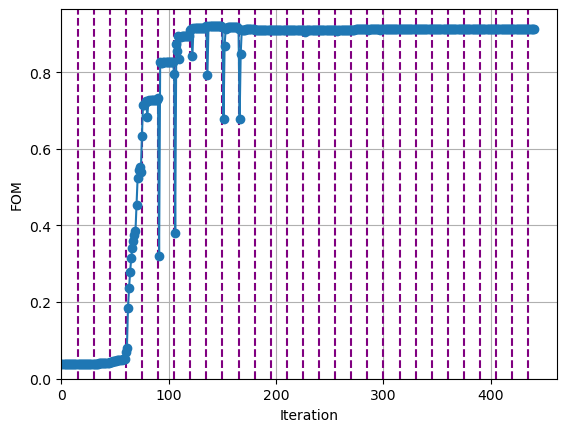

plot the fom_change.png


In [7]:
evaluation_history = result['evaluation_history']
plt.figure()
# Add vertical dashed lines at intervals of num_betas
for i in range(1, len(evaluation_history)//update_factor+1):
    plt.axvline(x=update_factor * i, color='purple', linestyle='--')
plt.plot(evaluation_history, "o-")
plt.grid(True)
plt.xlabel("Iteration")
plt.ylabel("FOM")
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.savefig(f'{dir_path}/fom_change.png')
plt.show()
plt.close()
print('plot the fom_change.png')

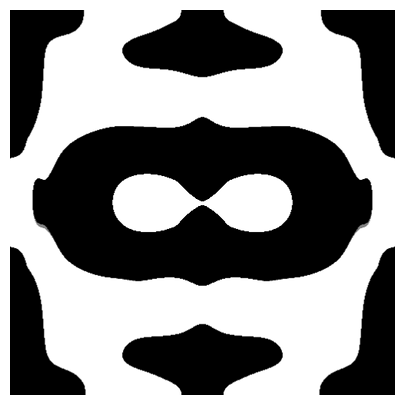

In [5]:
design = result['final_design']
opt.update_design([design]) # cur_beta/beta_scale is the final beta in the optimization.
plt.figure(figsize=(5,5))
ax = plt.gca()
opt.plot2D(
    False,
    ax=ax,
    plot_sources_flag=False,
    plot_monitors_flag=False,
    plot_boundaries_flag=False,
    output_plane = mp.Volume(center=mp.Vector3(0,0,0), size=mp.Vector3(dx, dy, 0))
)
circ = Circle((2, 2), minimum_length / 2)
ax.add_patch(circ)
ax.axis("off")
plt.savefig(f'{dir_path}/final_st.png',transparent=True)
plt.show()
plt.close()

In [12]:
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable
opt.sim =mp.Simulation(
    cell_size=cell_size,
    boundary_layers=pml_layers,
    geometry=geometry,
    sources=source,
    default_material=Air,
    k_point=kpoint,
    resolution=resolution,
    extra_materials=[Si],
)
 
src = mp.ContinuousSource(frequency=frequencies[0], fwidth=0.01, is_integrated=True)
source = [mp.Source(src, component=mp.Ey, size=source_size, center=source_center)]
opt.sim.change_sources(source)

dft_fields = opt.sim.add_dft_fields([mp.Dy,mp.Ey],
                                fcen,0,1,
                                center=mp.Vector3(),
                                size=mp.Vector3(Sx,Sy,0),
                                )
opt.sim.run(until=50)
Ey = opt.sim.get_dft_array(dft_fields,mp.Ey,0)
amplitude = np.abs(Ey) ** 2
[x, y, z, w] = opt.sim.get_array_metadata(dft_cell=dft_fields)

FloatProgress(value=0.0, description='0% done ', max=50.0)

(502, 2502)


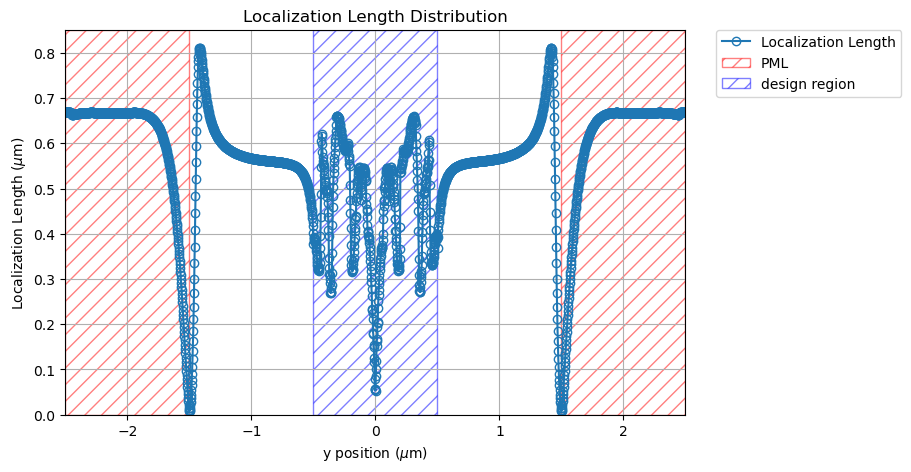

In [15]:
from scipy import integrate
print(amplitude.shape)

# Define x-coordinates
x = np.linspace(-0.5, 0.5, 502)  
amplitude_2 = np.power(amplitude, 2)  # Square of amplitude

# Store localization lengths for different modes
localization_length = []

for i in range(amplitude.shape[1]):  # Loop over modes
    Ey_2 = integrate.simpson(amplitude[:, i], x=x)  # ∫|Ey|^2 dx
    Ey_4 = integrate.simpson(amplitude_2[:, i], x=x)  # ∫|Ey|^4 dx
    length = (Ey_4 / (Ey_2**2))**(-1)  # Localization length formula
    localization_length.append(length)

# Convert list to NumPy array for plotting
localization_length = np.array(localization_length)

# Define PML regions (assuming they are at both ends)
pml_region = 500  # Number of points for PML on each side
y_indices = np.arange(amplitude.shape[1])

# Create figure
fig, ax = plt.subplots(figsize=(8, 5))

# Plot localization length
ax.plot(y, localization_length, marker='o', linestyle='-', markerfacecolor='none',
        markeredgecolor='tab:blue', color='tab:blue', label='Localization Length')

# Highlight PML and design regions
ax.axvspan(-Sy/2, -Sy/2+pml_size, facecolor='white', edgecolor='red', alpha=0.5, hatch='//', label='PML')
ax.axvspan(Sy/2 - pml_size, Sy/2, facecolor='white', edgecolor='red', alpha=0.5, hatch='//')
ax.axvspan(-dy/2, dy/2, facecolor='white', edgecolor='blue', alpha=0.5, hatch='//', label='design region')

# Labels and title
ax.set_xlabel("y position ($\mu$m)")
ax.set_ylabel("Localization Length ($\mu$m)")
ax.set_title("Localization Length Distribution")

# Set legend outside the plot
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)

ax.set_xlim(-Sy/2,Sy/2)
ax.set_ylim(0,)


# Add grid
ax.grid()

# Save and show plot
plt.savefig(f'{dir_path}/localization2.svg', transparent=True, bbox_inches='tight')
plt.show()
plt.close()




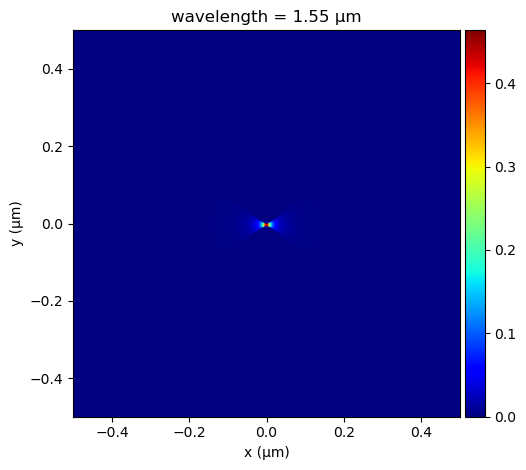

In [13]:

plt.title('wavelength = '+str(wavelengths[0])+' μm')
plt.pcolormesh(
        x,
        y,
        np.transpose(amplitude),
        cmap="jet",
        shading="gouraud",
        vmin=0,
        vmax=np.amax(amplitude),
    )
plt.gca().set_aspect("equal")
plt.xlabel("x (μm)")
plt.ylabel("y (μm)")
plt.ylim(-0.5,0.5)

# ensure that the height of the colobar matches that of the plot
divider = make_axes_locatable(plt.gca())
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(cax=cax)
plt.tight_layout()
# plt.savefig(f'{dir_path}/yz_s.svg')
plt.savefig(f'{dir_path}/xy_s.png')
plt.show()
plt.close()



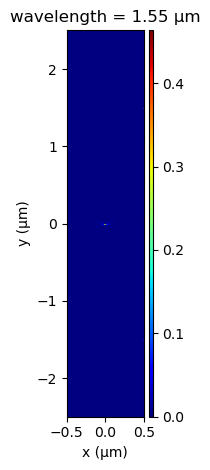

In [14]:
plt.title('wavelength = '+str(wavelengths[0])+' μm')
plt.pcolormesh(
        x,
        y,
        np.transpose(amplitude),
        cmap="jet",
        shading="gouraud",
        vmin=0,
        vmax=np.amax(amplitude),
    )
plt.gca().set_aspect("equal")
plt.xlabel("x (μm)")
plt.ylabel("y (μm)")
# ensure that the height of the colobar matches that of the plot
divider = make_axes_locatable(plt.gca())
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(cax=cax)
plt.tight_layout()
# plt.savefig(f'{dir_path}/yz_s.svg')
plt.savefig(f'{dir_path}/xy.png')
plt.show()
plt.close()

opt.sim.reset_meep()

## Q-factor

In [16]:
mp.verbosity(1)
opt.sim.reset_meep()
src = mp.GaussianSource(frequency=frequencies[0], fwidth=0.1)
source = [mp.Source(src, component=mp.Ey, size= mp.Vector3(), center= mp.Vector3())]
opt.sim.change_sources(source)
h=mp.Harminv(mp.Ey, pt=mp.Vector3(0, 0), fcen=frequencies[0], df=0.2)
opt.sim.run(mp.after_sources(h),until = 500)  # Run simulation
harminv_results = h.modes
print(harminv_results)  # View results

-----------
Initializing structure...
time for choose_chunkdivision = 0.00200319 s
Working in 2D dimensions.
Computational cell is 1 x 5 x 0 with resolution 500
     block, center = (0,0,0)
          size (1,1,0)
          axes (1,0,0), (0,1,0), (0,0,1)
time for set_epsilon = 2.10851 s
-----------


FloatProgress(value=0.0, description='0% done ', max=500.0)

Meep progress: 0.22/500.0 = 0.0% done in 4.0s, 9117.7s to go
on time step 220 (time=0.22), 0.0182276 s/step
Meep progress: 0.453/500.0 = 0.1% done in 8.0s, 8843.3s to go
on time step 453 (time=0.453), 0.0171862 s/step
Meep progress: 0.687/500.0 = 0.1% done in 12.0s, 8737.5s to go
on time step 687 (time=0.687), 0.0170999 s/step
Meep progress: 0.922/500.0 = 0.2% done in 16.0s, 8677.0s to go
on time step 922 (time=0.922), 0.0170527 s/step
Meep progress: 1.157/500.0 = 0.2% done in 20.0s, 8639.3s to go
on time step 1157 (time=1.157), 0.0170507 s/step
Meep progress: 1.594/500.0 = 0.3% done in 24.0s, 7517.2s to go
on time step 1594 (time=1.594), 0.0091592 s/step
Meep progress: 2.343/500.0 = 0.5% done in 28.1s, 5959.4s to go
on time step 2343 (time=2.343), 0.00535739 s/step
Meep progress: 2.583/500.0 = 0.5% done in 32.1s, 6174.3s to go
on time step 2583 (time=2.583), 0.0166807 s/step
Meep progress: 2.819/500.0 = 0.6% done in 36.1s, 6363.2s to go
on time step 2819 (time=2.819), 0.0170144 s/step

/home/yucheng/anaconda3/envs/mp/lib/python3.8/site-packages/meep/simulation.py:1167: RuntimeWarning: Harminv frequency 0.7451612903225806 is outside maximum Source frequency 0.6951612903225807
  warnings.warn(warn_fmt.format(harminv_max, sf_max), RuntimeWarning)
/home/yucheng/anaconda3/envs/mp/lib/python3.8/site-packages/meep/simulation.py:1170: RuntimeWarning: Harminv frequency 0.5451612903225806 is outside minimum Source frequency 0.5951612903225806
  warnings.warn(warn_fmt.format(harminv_min, sf_min), RuntimeWarning)


In [17]:
import pandas as pd
data = [
    {
        "frequency": mode.freq,         # Real frequency
        "decay": mode.decay,      # Imaginary frequency
        "Q_factor": mode.Q,             # Quality factor
        "abs_amplitude": abs(mode.amp), # Absolute value of amplitude
        "amplitude": mode.amp,          # Amplitude (complex value)
        "error": mode.err               # Error in frequency estimation
    }
    for mode in h.modes  # Iterate over harminv_instance.modes
]
# Convert list to Pandas DataFrame
df = pd.DataFrame(data)
# Save DataFrame to CSV
df.to_csv(f"{dir_path}/harminv_results.csv", index=False)
print("Harminv results saved as harminv_results.csv")

Harminv results saved as harminv_results.csv
